## Embeddings en OpenAI usando el modelo : text-embedding-ada-002

In [1]:
from openai import OpenAI
import os, getpass

In [2]:
os.environ["OPENAI_API_KEY"] = getpass.getpass("Ingresa tu API Key de OpenAI : ")

In [3]:
client = OpenAI()

In [4]:
def generate_embedding_openai(text, model = "text-embedding-ada-002"):
   text = text.replace("\n", " ")
   response = client.embeddings.create(
      input = text,
      model = model
   )
   return response.data[0].embedding

In [5]:
embedding = generate_embedding_openai("Me gusta la comida china")

In [ ]:
embedding

In [7]:
len(embedding)

1536

In [7]:
len(embedding)

1536

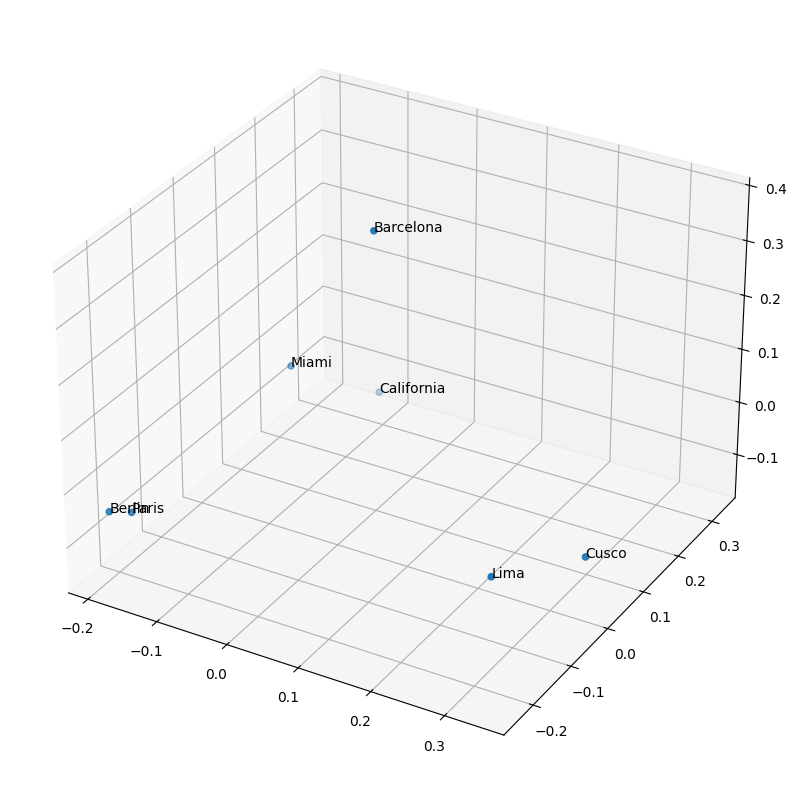

In [8]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

cities = ["Lima", "Cusco", "Berlin", "Paris", "California", "Barcelona", "Miami"]
df = pd.DataFrame({"city" : cities})

# Genera embeddings para cada ciudad utilizando la función 'generate_embedding_openai'
# y almacenar estos embeddings en una nueva columna llamada 'cities_embeddings'.
df["cities_embeddings"] = [generate_embedding_openai(city) for city in cities]

# Inicializa el algoritmo PCA para reducir la dimensionalidad a 3 componentes.
pca = PCA(n_components = 3)

# Aplica PCA a los embeddings de las ciudades y almacenar el resultado en 't'.
t = pca.fit_transform(df['cities_embeddings'].tolist())

# Inicializar una figura para la visualización con un tamaño específico.
fig = plt.figure(figsize = (10,20))
ax = fig.add_subplot(111, projection = "3d")

# Graficar los puntos en 3D usando los resultados de PCA.
ax.scatter(t[:,0], t[:,1], t[:,2])

# Anotar cada punto con el nombre de la ciudad correspondiente.
for i, txt in enumerate(cities):
    ax.text(t[i,0], t[i,1], t[i,2], txt)

plt.show()

## Embeddings usando el modelo : all-MiniLM-L6-v2

In [9]:
from sentence_transformers import SentenceTransformer
sentences = ["Me gusta la pizza"]

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embeddings = model.encode(sentences)
print(embeddings)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:02<00:00, 49.03it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[[-4.70177718e-02  6.64309086e-03 -1.09591298e-02 -2.71865888e-03
  -7.77251646e-02  2.68589035e-02  1.26107886e-01  1.41473562e-02
   8.41322243e-02 -1.21767884e-02  4.41410542e-02 -7.74307027e-02
  -8.66881944e-03 -6.23227321e-02  2.48122755e-02 -7.62215629e-02
   9.30181146e-02  1.48365442e-02 -2.18283106e-02  2.35640667e-02
  -4.09047455e-02 -8.64248071e-03 -1.03656575e-01  8.38767812e-02
  -8.02415684e-02  4.14154045e-02 -2.35767057e-03 -1.75159369e-02
  -1.61437243e-02 -7.95997381e-02  5.49245486e-03  1.12108521e-01
   3.16147469e-02 -1.22960443e-02  4.76883492e-03 -5.26420446e-03
   2.64710300e-02 -1.28910303e-01  5.59662879e-02  1.09010018e-01
  -4.04209718e-02  1.75845381e-02  4.85426933e-02 -7.66265020e-02
   2.61696223e-02 -6.24619238e-03 -2.37196647e-02  5.72243445e-02
   5.65814041e-02  1.41139161e-02 -7.74052739e-02  6.40973123e-03
  -3.83057934e-03 -2.47235354e-02 -5.18747419e-03  5.61187975e-02
   3.85534726e-02  3.08667566e-03  1.00962177e-01  3.12015619e-02
  -1.25184

In [10]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')

emb1 = model.encode("Me gusta la comida china")
emb2 = model.encode("No me gusta ir a la playa")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6574.14it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
len(emb1), len(emb2)

(384, 384)

In [12]:
def generate_embedding_all_MiniLM(text):
   text = text.replace("\n", " ")
   return model.encode(text)

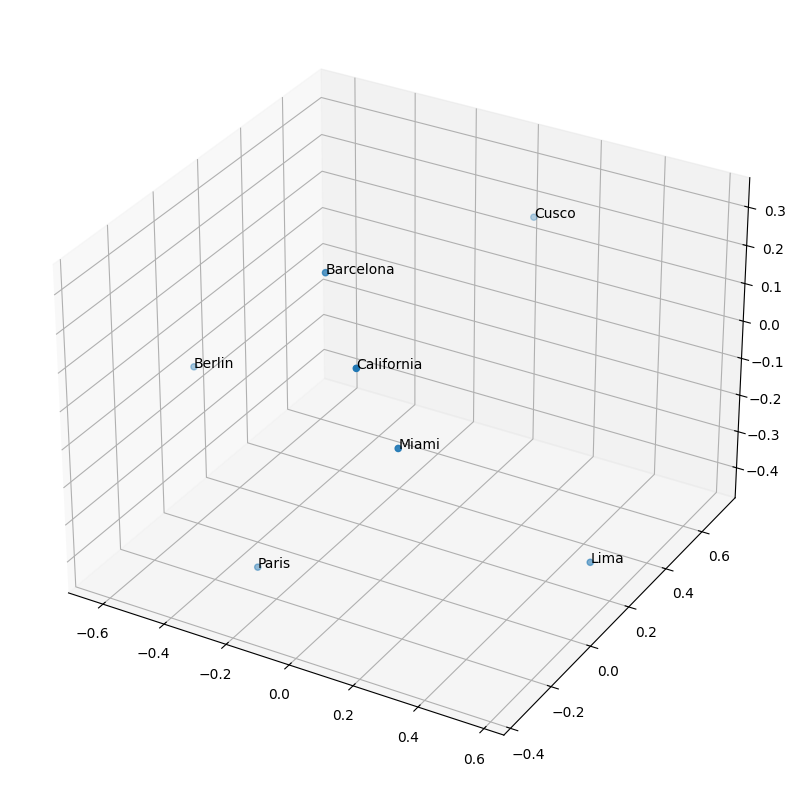

In [13]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

cities = ["Lima", "Cusco", "Berlin", "Paris", "California", "Barcelona", "Miami"]
df = pd.DataFrame({"city" : cities})

# Genera embeddings para cada ciudad utilizando la función 'generate_embedding_all_MiniLM'
# y almacenar estos embeddings en una nueva columna llamada 'cities_embeddings'.
df["cities_embeddings"] = [generate_embedding_all_MiniLM(city) for city in cities]

# Inicializa el algoritmo PCA para reducir la dimensionalidad a 3 componentes.
pca = PCA(n_components = 3)

# Aplica PCA a los embeddings de las ciudades y almacenar el resultado en 't'.
t = pca.fit_transform(df['cities_embeddings'].tolist())

# Inicializar una figura para la visualización con un tamaño específico.
fig = plt.figure(figsize = (10,20))
ax = fig.add_subplot(111, projection = "3d")

# Graficar los puntos en 3D usando los resultados de PCA.
ax.scatter(t[:,0], t[:,1], t[:,2])

# Anotar cada punto con el nombre de la ciudad correspondiente.
for i, txt in enumerate(cities):
    ax.text(t[i,0], t[i,1], t[i,2], txt)

plt.show()